In [ ]:
"""
Test script for the regularized Thomson scattering fitter.

Generates a synthetic EPW streak from the profiles defined in forward_test.py,
adds 5% Gaussian noise, then scans over Tikhonov penalty weights and thresholds
using chi2_vary_tikhonov to produce an L-curve-style diagnostic plot.

Ion parameters (Ti, ui, pi, ifract) are held fixed at their true values.
Electron parameters (n, Te, ue) are fitted with 2nd-derivative Tikhonov
penalties. pe and efract are also free but unpenalized.
"""

import numpy as np
import matplotlib.pyplot as plt

from forward import _scattered_power_wavelength
from fitting import chi2_vary_tikhonov, _log_likelihood
from utility import extract_params_as_array
from scipy.constants import e, k as kB
import matplotlib.colors as mcolors


In [ ]:

# ---------- True plasma profiles (forward_test.py lines 10-24) ----------
# Using actual time axis (not zeroed out) for meaningful time-varying profiles.

Nt = 11
t = np.linspace(0, 3, Nt)   # ns
tau = 1.5

ne_true    = 1e20 * np.exp(-t / tau)
ue_true    = 1e6  * np.exp(-np.sqrt(t / tau))
ui_true    = ue_true + 2e5 * np.exp(-t / tau) - 1e5
Te_true    = 1000  * np.exp(-t / tau)
Ti_true    = 2000  - np.sqrt(t) * 100
ifractC    = 0.05 * t**2      # carbon charge fraction
ifractD    = 1 - ifractC      # deuterium charge fraction


# ---------- Measurement geometry (forward_test.py lines 30-45) ----------

def sph2cart(phi, theta):
    phi   = phi   / 180 * np.pi
    theta = theta / 180 * np.pi
    v = np.array([np.sin(phi) * np.cos(theta),
                  np.sin(phi) * np.sin(theta),
                  np.cos(phi)])
    return v / np.linalg.norm(v)

probe_wavelength = 263.25e-9   # m
epw_lam = np.linspace(230 - 30, 230 + 30, 1024) * 1e-9   # m

probe_vec   = sph2cart(116.57, 18)
scatter_vec = -sph2cart(112.15, 162)
k_vec       = scatter_vec - probe_vec
k_vec       = k_vec / np.linalg.norm(k_vec)
notch       = np.array([probe_wavelength - 1, probe_wavelength + 1])*1e-9

# ---------- Generate synthetic EPW spectrum ----------

Pkl_true = _scattered_power_wavelength(
    n               = ne_true * 1e6,
    Te              = np.array([Te_true]) * e / kB,
    Ti              = np.array([Ti_true, Ti_true]) * e / kB,
    ue              = np.array([ue_true]),
    ui              = np.array([ui_true, ui_true]),
    pe              = np.ones((1, Nt)) * 2,
    pi              = np.ones((2, Nt)) * 2,
    efract          = np.ones((1, Nt)),
    ifract          = np.array([ifractD, ifractC]),
    ion_z           = np.array([1.0, 6.0]),
    ion_a           = np.array([2.0, 12.0]),
    wavelengths     = epw_lam,
    probe_wavelength= probe_wavelength,
    probe_vec       = probe_vec,
    scatter_vec     = scatter_vec,
    ue_dir          = k_vec,
    ui_dir          = k_vec,
    notch           = notch * 1e-9,
    normalization_type="integral"
)
Pkl_true = np.array(Pkl_true)   # (Nk, Nt)


In [ ]:
# ---------- Plot true profiles ----------

fig_prof, axes_prof = plt.subplots(2, 3, figsize=(14, 7), sharex=True)
axes_prof[0, 0].plot(t, ne_true);        axes_prof[0, 0].set_title("ne (m⁻³)")
axes_prof[0, 1].plot(t, Te_true);        axes_prof[0, 1].set_title("Te (eV)")
axes_prof[0, 2].plot(t, ue_true);        axes_prof[0, 2].set_title("ue (m/s)")
axes_prof[1, 0].plot(t, Ti_true);        axes_prof[1, 0].set_title("Ti (eV)")
axes_prof[1, 1].plot(t, ifractC);        axes_prof[1, 1].set_title("C charge frac.")
axes_prof[1, 2].plot(t, ifractD);        axes_prof[1, 2].set_title("D charge frac.")
for ax in axes_prof[1]: ax.set_xlabel("t (ns)")
fig_prof.suptitle("True plasma profiles")
plt.tight_layout()


# ---------- Plot true streak ----------

fig_streak, ax_streak = plt.subplots(figsize=(8, 5))
lam_nm = epw_lam * 1e9
pcm = ax_streak.pcolormesh(t, lam_nm, Pkl_true, shading="auto", cmap="inferno")
plt.colorbar(pcm, ax=ax_streak, label="Scattered power (norm.)")
ax_streak.set_xlabel("t (ns)")
ax_streak.set_ylabel("Wavelength (nm)")
ax_streak.set_title("True Thomson EPW streak")
plt.tight_layout()

plt.show()   # ── block here; close windows to proceed to chi2 scan ──

In [ ]:

# ---------- Add 5% Gaussian noise ----------
fig_streak, ax_streak = plt.subplots(figsize=(8, 5))
rng        = np.random.default_rng(42)
noise_level = 0.1*np.max(Pkl_true)
Pkl_data   = Pkl_true + rng.normal(0, noise_level, size=Pkl_true.shape)
Pkl_var    = noise_level**2
pcm = ax_streak.pcolormesh(t, lam_nm, Pkl_data, shading="auto", cmap="inferno")
plt.colorbar(pcm, ax=ax_streak, label="Scattered power (norm.)")
ax_streak.set_xlabel("t (ns)")
ax_streak.set_ylabel("Wavelength (nm)")
ax_streak.set_title("True Thomson EPW streak")
plt.tight_layout()

plt.show()   # ── block here; close windows to proceed to chi2 scan ──

print(_log_likelihood(Pkl_true, Pkl_data, Pkl_var))

In [ ]:



# ---------- Measurement settings dict ----------

measurement_settings = {
    "Nelectrons"      : 1,
    "ion_z"           : np.array([1.0, 6.0]),
    "ion_a"           : np.array([2.0, 12.0]),
    "wavelengths"     : epw_lam,
    "probe_wavelength": probe_wavelength,
    "probe_vec"       : probe_vec,
    "scatter_vec"     : scatter_vec,
    "ue_dir"          : k_vec,
    "ui_dir"          : k_vec,
    "normalization_type": "integral",
}


# ---------- params_settings ----------
# Electrons: flat initial guesses, free to vary.
# Ions: true time-varying profiles, held fixed (vary=False).

params_settings = {
    "n"      : {"value": 1e20,  "vary": True, "min": 1e18, "max": 1e21},
    "Te"     : {"value": 500.0, "vary": True, "min": 10, "max": 10000},
    "ue"     : {"value": 5e6,   "vary": True, "min": 0, "max": 1e7},
    "pe"     : {"value": 2.0,   "vary": False,},
    "efract" : {"value": 1.0,   "vary": False},
    # Ion species fixed at true profiles — one entry per (species, timestep).
    **{f"Ti0_{i}":     {"value": float(Ti_true[i]),  "vary": False} for i in range(Nt)},
    **{f"Ti1_{i}":     {"value": float(Ti_true[i]),  "vary": False} for i in range(Nt)},
    **{f"ui0_{i}":     {"value": float(ui_true[i]),  "vary": False} for i in range(Nt)},
    **{f"ui1_{i}":     {"value": float(ui_true[i]),  "vary": False} for i in range(Nt)},
    **{f"pi0_{i}":     {"value": 2.0,                "vary": False} for i in range(Nt)},
    **{f"pi1_{i}":     {"value": 2.0,                "vary": False} for i in range(Nt)},
    **{f"ifract0_{i}": {"value": float(ifractD[i]),  "vary": False} for i in range(Nt)},
    **{f"ifract1_{i}": {"value": float(ifractC[i]),  "vary": False} for i in range(Nt)},
}


# ---------- Penalty settings: 2nd-derivative Tikhonov on n, Te, ue ----------
# lambda_weights[k] weights the k-th derivative; indices 0 and 1 are zero
# so only the 2nd derivative is penalized.  Thresholds are absolute (relative=False).

base_penalty_settings = {
    "n" : {
        "profile_axis"  : t,
        "lambda_weights": [0.0, 0.1, 1.0],
        "thresholds"    : [0.0, 1, 1],   # ~0.1% of peak ne
        "relative"      : True,
    },
    "Te": {
        "profile_axis"  : t,
        "lambda_weights": [0.0, 0.1, 1.0],
        "thresholds"    : [0.0, 1, 1],    # 1 eV
        "relative"      : True,
    },
    "ue": {
        "profile_axis"  : t,
        "lambda_weights": [0.2, 1.0, 0.0],
        "thresholds"    : [2e6, 1e5, 0],    # 10 km/s
        "relative"      : False,
        "norm_scale"    : [0.5e6, 1e5, 1e5],
        "monotonic"     : [0, 1, 0]
    },
}



run_fit (nelder): 15836iter [24:26, 10.80iter/s, obj=25.95, d_obj=3.67e-07]


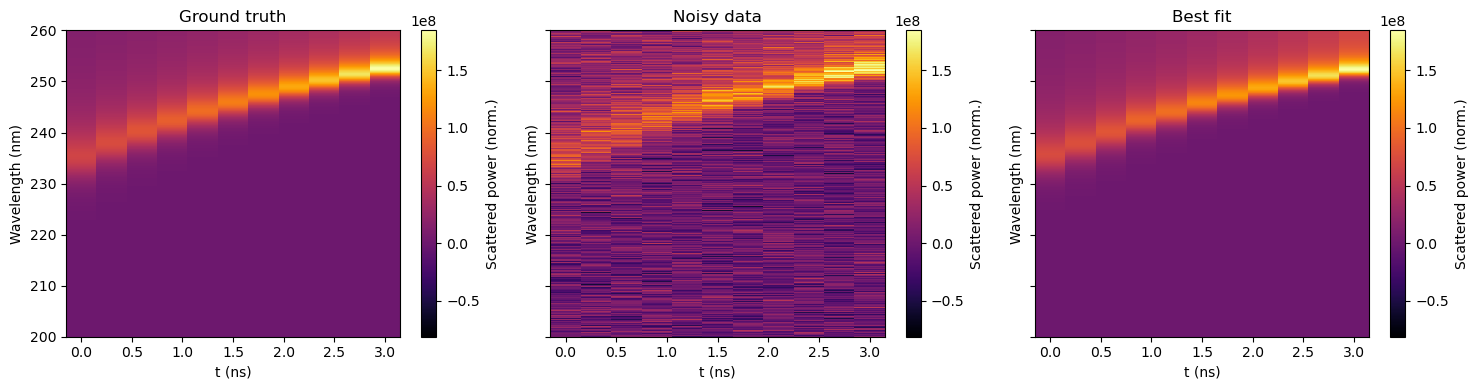

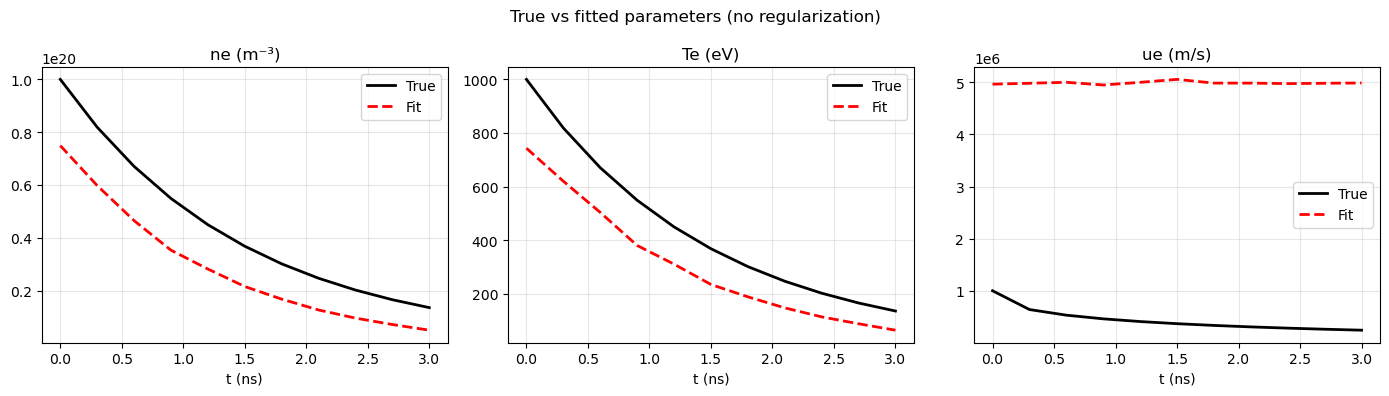

In [23]:
from fitting import run_fit

# ---------- Single unregularized fit ----------

penalty_settings = {
    "n" : {
        "profile_axis"  : t,
        "lambda_weights": [0.0, 0.01, 0.04],
        "thresholds"    : [0.0, 0.0, 0.0],   # ~0.1% of peak ne
        "relative"      : True,
    },
    "Te": {
        "profile_axis"  : t,
        "lambda_weights": [0.0, 0.01, 0.04],
        "thresholds"    : [0.0, 0.0, 0.0],    # 1 eV
        "relative"      : True,
    },
    "ue": {
        "profile_axis"  : t,
        "lambda_weights": [1, 0, 0],
        "thresholds"    : [0.0, 0, 0],    # 10 km/s
        "relative"      : False,
        "norm_scale"    : [1e6, 1e5, 1e5],
        "monotonic"     : [1, 1, 0]
    },
}

result, best_fit = run_fit(
    Pkl_data, Pkl_var,
    measurement_settings,
    penalty_settings=penalty_settings,
    params_settings=params_settings,
    progress=True
)
best_fit = np.array(best_fit)

# ---------- Spectra: ground truth | noisy data | best fit ----------

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
vmin = min(Pkl_true.min(), Pkl_data.min())
vmax = Pkl_true.max()

for ax, data, title in zip(
    axes,
    [Pkl_true, Pkl_data, best_fit],
    ["Ground truth", "Noisy data", "Best fit"],
):
    pcm = ax.pcolormesh(t, lam_nm, data, shading="auto", cmap="inferno",
                        vmin=vmin, vmax=vmax)
    plt.colorbar(pcm, ax=ax, label="Scattered power (norm.)")
    ax.set_xlabel("t (ns)")
    ax.set_ylabel("Wavelength (nm)")
    ax.set_title(title)

plt.tight_layout()
plt.show()

# ---------- Parameter profiles: true vs fitted ----------

fitted_n   = extract_params_as_array(result.params, "n",   Nt)
fitted_Te  = extract_params_as_array(result.params, "Te0", Nt)
fitted_ue  = extract_params_as_array(result.params, "ue0", Nt)

params_to_plot = [
    ("ne (m⁻³)", ne_true, fitted_n),
    ("Te (eV)",  Te_true, fitted_Te),
    ("ue (m/s)", ue_true, fitted_ue),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharex=True)
for ax, (label, true_vals, fit_vals) in zip(axes, params_to_plot):
    ax.plot(t, true_vals, "k-",  linewidth=2, label="True")
    ax.plot(t, fit_vals,  "r--", linewidth=2, label="Fit")
    ax.set_xlabel("t (ns)")
    ax.set_title(label)
    ax.legend()
    ax.grid(True, alpha=0.3)

fig.suptitle("True vs fitted parameters (no regularization)")
plt.tight_layout()
plt.show()

In [ ]:

# ---------- Scan penalty parameter space ----------

weight_scales = np.logspace(-4, 1, 6)   # 0.01 → 10000
cutoff_scales = np.logspace(0, 0, 1)   # 0.1  → 10

chi2_grid, params_grid = chi2_vary_tikhonov(
    Pkl_data, Pkl_var,
    measurement_settings,
    base_penalty_settings,
    weight_scales,
    cutoff_scales,
    params_settings=params_settings,
    progress=True
)


In [ ]:
# ---------- Plot chi2 grid ----------

def log_bin_edges(centers):
    """Bin edges that are geometric midpoints between log-spaced centers."""
    log_c = np.log10(centers)
    d = np.diff(log_c)
    edges = np.concatenate([
        [log_c[0] - d[0] / 2],
        (log_c[:-1] + log_c[1:]) / 2,
        [log_c[-1] + d[-1] / 2],
    ])
    return 10**edges

x_edges = log_bin_edges(cutoff_scales)
y_edges = log_bin_edges(weight_scales)

fig, ax = plt.subplots(figsize=(8, 5))
pcm = ax.pcolormesh(x_edges, y_edges, np.array(chi2_grid),
    shading="flat", cmap="viridis",
)
plt.colorbar(pcm, ax=ax, label="Chi2 (log likelihood, no regularization)")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Threshold scale")
ax.set_ylabel("Weight scale")
ax.set_title("Chi2 vs Tikhonov penalty parameters")
plt.tight_layout()
#plt.savefig("chi2_tikhonov_scan.png", dpi=150)
plt.show()

In [ ]:
params_grid[0][0].keys()

In [ ]:
# ---------- Plot fitted parameters vs true parameters ----------
# Color varies by cutoff scale, opacity (alpha) varies by weight scale

# Create colormaps for cutoff scales and weight scales
cutoff_colors = plt.cm.tab10(np.linspace(0, 1, len(cutoff_scales)))
weight_alphas = np.linspace(0.3, 1.0, len(weight_scales))

# Parameters to plot
params_to_plot = [("n", ne_true), ("Te0", Te_true), ("ue0", ue_true)]

fig_fit, axes_fit = plt.subplots(1, 3, figsize=(15, 4), sharex=True)

for ax_idx, (param_name, true_values) in enumerate(params_to_plot):
    ax = axes_fit[ax_idx]

    # Plot true profile
    ax.plot(t, true_values, "k-", linewidth=2.5, label="True", zorder=10, linestyle='--')

    # Plot each fitted profile
    for i, ws in enumerate(weight_scales):
        for j, cs in enumerate(cutoff_scales):
            fitted_dict = params_grid[i][j]
            fitted_array = extract_params_as_array(fitted_dict, param_name, Nt)

            alpha = weight_alphas[i]
            color = cutoff_colors[j]
            ax.plot(t, fitted_array, "-", color=color, alpha=alpha, linewidth=1.0)

    ax.set_xlabel("t (ns)")
    ax.set_ylabel(f"{param_name}")
    ax.set_title(f"{param_name} fits vs true")
    ax.grid(True, alpha=0.3)

# Add custom legend explaining color and alpha scheme
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], color="k", lw=2.5, label="True profile")]
for j, cs in enumerate(cutoff_scales):
    legend_elements.append(Line2D([0], [0], color=cutoff_colors[j], lw=2, label=f"Cutoff scale = {cs:.2f}"))
legend_elements.append(Line2D([0], [0], color="gray", lw=1, label="(opacity = weight scale)"))

fig_fit.legend(handles=legend_elements, loc="upper center", bbox_to_anchor=(0.5, -0.05), ncol=2)
fig_fit.suptitle("Fitted parameters for different Tikhonov penalty scales")
plt.tight_layout(rect=[0, 0.08, 1, 0.96])
plt.show()
